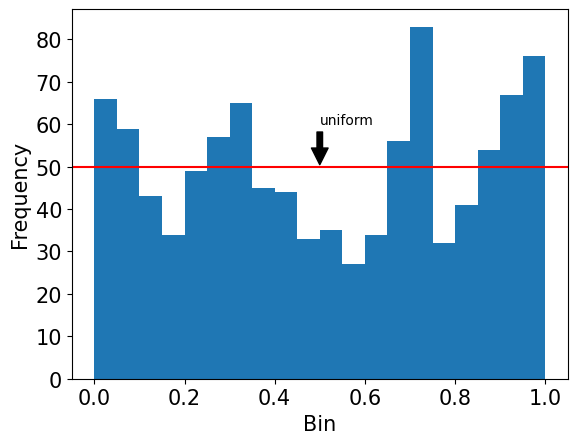

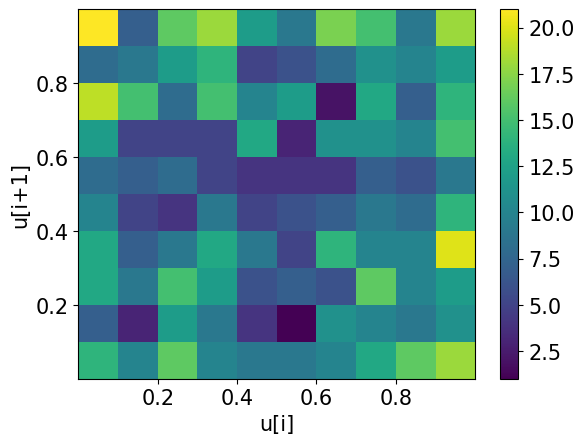

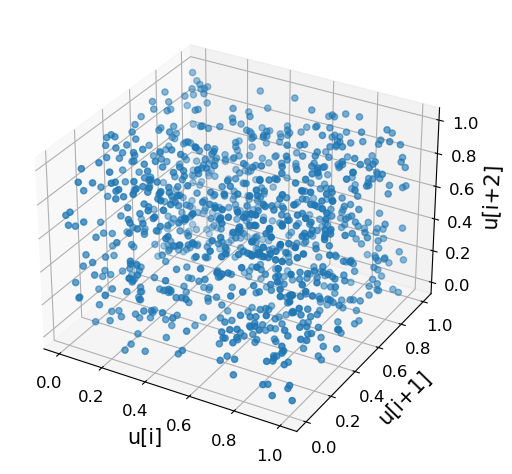

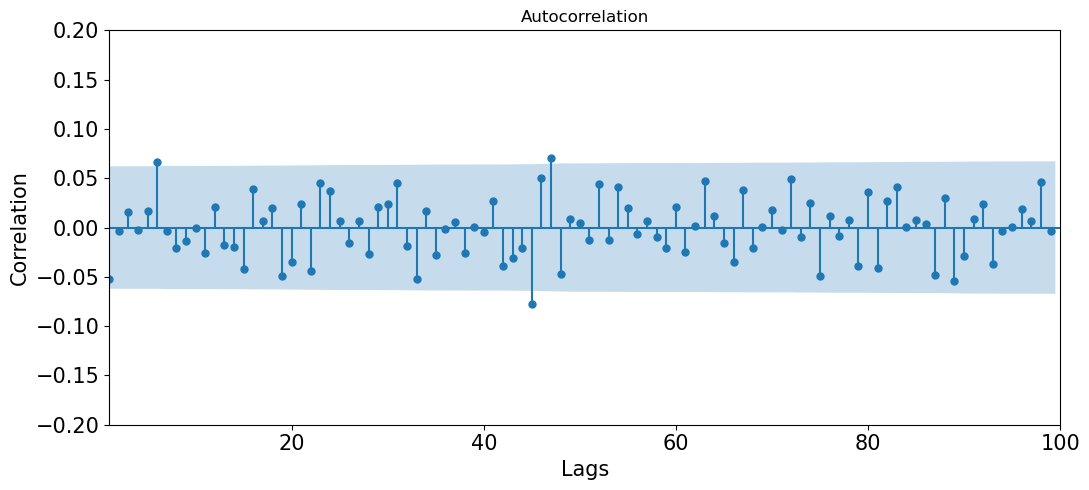

In [1]:
#tausworth5
# 
## code to generate uniform random numbers
## via the Tausworthe (1965) algorithm
## 
#########
## CELL 1 Generate uniforms and graphs
#########
def b_i(b,q,r):
    # given a list of binary digits b, and parameters q and r,
    #generate b_i recursively from b[i-1...]
    i = len(b)
    return b[i-r]^b[i-q]

def init_b(b,el):
    # add a digit to initial binary list
    for i in range(el):
        b.append(b_i(b,q,r))
    return b

def make_words(b,el):
    # given a binary list b and a word length el,
    # make a word (uniform PRN)  
    for i in range(int(len(b)/el)):
        v = 0
        for j in range(el):
            v += b[el*i+j]*2**(el-1-j)

    return v/2**el
   
def update_b(b,q,r):
    # update the binary list--add one number and drop last 
    b.append(b_i(b,q,r))
    b.pop(0)
    return b

def set_seed(q,el):
    # set the seed to all ones (change this as desired)
    # note that fixed vectors contain at most two "1" values
    # thus this will not produce a fixed vector
    return [1]*max(q,el)

def make_u(q,r,el,n):
    # given recurrent parameters and desired number of outputs,
    # make uniform PRNs
    # this calls the routines above
    b = set_seed(q,el)
    b=init_b(b,el)
    
    u = list()

    for i in range(n):
        for j in range(el):
            b=update_b(b,q,r)
        u.append(make_words(b,el))

    return u

def gen_norm(u):
    # given list of uniformly distributed PRNs, make normals via Box-Muller
    from numpy import sqrt,pi, log, cos, sin
    n = int(len(u)/2)
    u1 = u[:n]
    u2 = u[n:]
    z1 = [sqrt(-2*log(u1i))*cos(2*pi*u2i) for u1i,u2i in zip(u1,u2)]
    z2 = [sqrt(-2*log(u1i))*sin(2*pi*u2i) for u1i,u2i in zip(u1,u2)]
    z1.extend(z2)
    return z1 

#
# set parameters here
#

q = 31
r = 7
el = 20
n = 1000
nlag = 100 # for autocorrelation function
nbins = 20 #for histogram

u = make_u(q,r,el,n)

#
# draw histogram, 2d, 3d graphs, autocorrelation
#

def make_graphs(u,nbins):
    # given u PRN series (list) and number of bins for uniform plot,
    # produce the graphs in the paper

    # U() histogram

    import matplotlib.pyplot as plt
    import numpy as np
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel("Bin",fontsize=15)
    plt.ylabel("Frequency",fontsize=15)
    plt.axhline(y=n/nbins, color='r', linestyle='-')
    plt.annotate('uniform', xy=(.5, 50), xytext=(.5, 60),
                arrowprops=dict(facecolor='black', shrink=0.05))
    plt.hist(u,bins=nbins)
    plt.savefig('Figure1.png')
    plt.show()
    
    # u(i) vs u(i+1) heatmap
    
    y = u[1:]
    x = u[:(len(u)-1)]
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel("u[i]",fontsize=15)
    plt.ylabel("u[i+1]",fontsize=15)
    plt.hist2d(x,y)
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=15)
    plt.savefig('Figure2.png')
    plt.show()
    
    # 3d embedding
    
    z = u[2:]
    y = u[1:(len(u)-1)]
    x = u[:(len(u)-2)]

    fig = plt.figure()
    
    ax = fig.add_subplot(projection='3d')
    ax.set_xlabel('u[i]',fontsize=15)
    ax.set_ylabel('u[i+1]',fontsize=15)
    ax.set_zlabel('u[i+2]',fontsize=15)
    ax.xaxis.set_tick_params(labelsize=12)
    ax.yaxis.set_tick_params(labelsize=12)
    ax.zaxis.set_tick_params(labelsize=12)
    ax.scatter(x,y,z)
    plt.tight_layout()
    plt.savefig('Figure3.png')
    plt.show()
    
    # Autocorrelation plot/test
    from statsmodels.graphics.tsaplots import plot_acf

    # Plot autocorrelation
    plt.rc("figure", figsize=(11,5))
    plot_acf(u, lags=range(1,nlag))
    plt.ylim(0,1)
    plt.xlabel('Lags', fontsize=15)
    plt.ylabel('Correlation', fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.xlim([1,nlag])
    plt.ylim([-.2,.2])
    plt.tight_layout()
    plt.savefig('Figure4.png')
    plt.show()

    
make_graphs(u,nbins)

In [2]:
#
#########
## CELL 2 perform statistical tests on the u_i series
#########
# 
#

def do_tests(u,nbins):

    #(1) 1D Chisquare for uniformity
    import numpy as np
    from scipy.stats import chisquare
    counts,bins=np.histogram(u,bins=nbins)
    chisq, chisq_p = chisquare(counts)
  
    #(2) lyung-box autocorrelation test
    
    from statsmodels.stats.diagnostic import acorr_ljungbox

    
    lb_df = acorr_ljungbox(u, lags=[nlag], return_df=True)
    lb = lb_df['lb_stat'].iat[0]
    lb_p = lb_df['lb_pvalue'].iat[0]
    
    #(3) runs test
    
    from statsmodels.sandbox.stats.runs import runstest_1samp 
    runs,runs_p = runstest_1samp(u,cutoff=.5)
    
    #(4) ARCH test
    
    from statsmodels.stats.diagnostic import het_arch
    arch,arch_p,_,_ = het_arch(np.array(u),nlags=20)
    
    #(5) bds test
    #https://www.statsmodels.org/devel/generated/statsmodels.tsa.stattools.bds.html
    
    from statsmodels.tsa.stattools import bds    
    bds,bds_p = bds(u, max_dim=2, epsilon=None, distance=1.5)
    
    
    # (6) anderson-darling test
        
    z1 = gen_norm(u)
      
    from statsmodels.stats.diagnostic import normal_ad
    ad,ad_p = normal_ad(np.array(z1))
    
    return {"chisq":chisq,"chisq_p":chisq_p,
            "lb":lb,"lb_p":lb_p,
            "arch":arch,"arch_p":arch_p,
            "runs":runs,"runs_p":runs_p,
            "bds":bds,"bds_p":bds_p,
            "ad":ad,"ad_p":ad_p}
    
do_tests(u,nbins)

{'chisq': 95.76,
 'chisq_p': 3.113973155067381e-12,
 'lb': 93.27712650277164,
 'lb_p': 0.6696830838317807,
 'arch': 21.0516217978344,
 'arch_p': 0.3940997742484416,
 'runs': 1.4586861989848612,
 'runs_p': 0.14465149632574958,
 'bds': array(-1.10277388),
 'bds_p': array(0.27012537),
 'ad': 0.9957355496280798,
 'ad_p': 0.012565993059606949}

In [3]:
#########
## CELL 3 two-level testing
#########
# generate ntests*1000 length U vector and 
# run tests on 100 successive 1000 length pieces

ntests = 100
n = 1000*ntests
nlag = 10 # for ljung-box

uu = make_u(q,r,el,n)

chisq_p = []
lb_p = []
arch_p = []
runs_p = []
bds_p = []
ad_p = []

for i in range(ntests):
    u = uu[i*int(n/ntests):(i*int(n/ntests)+int(n/ntests))]
    results = do_tests(u,nbins=20)
    chisq_p.append(results["chisq_p"])
    lb_p.append(results["lb_p"])
    arch_p.append(results["arch_p"])
    runs_p.append(results["runs_p"])
    bds_p.append(results["bds_p"])
    ad_p.append(results["ad_p"])
    
import pandas as pd
df = pd.DataFrame(zip(chisq_p,lb_p,arch_p,runs_p,bds_p,ad_p),columns=["chisq_p","lb_p","arch_p","runs_p","bds_p","ad_p"])
df.to_csv("2_level_tests.csv")

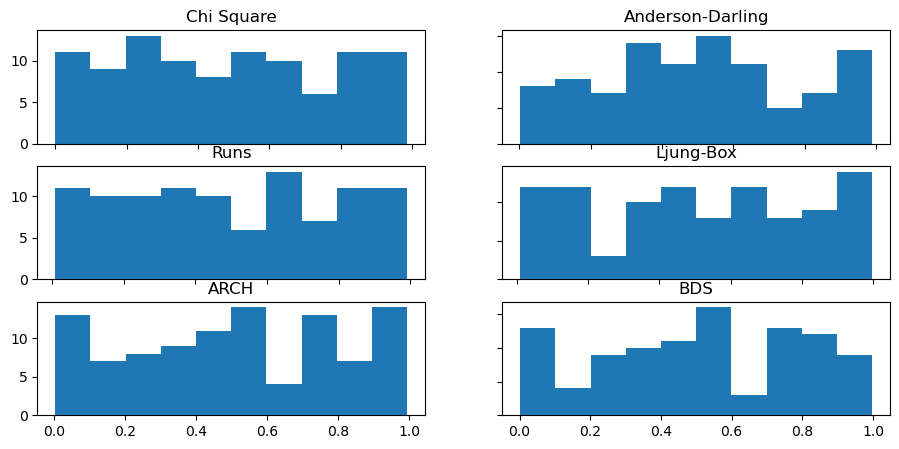

test result 0.9967902215553671
test result 0.34795643547828353
test result 0.8281768906911231
test result 0.4958850112232298
test result 0.06919680254089133
test result 0.2462658529094548


In [4]:
#########
## CELL 4 plot results of 2-level tests
#########

import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 2)
axs[0, 0].hist(chisq_p)
axs[0, 0].set_title('Chi Square')
axs[0, 1].hist(ad_p)
axs[0, 1].set_title('Anderson-Darling')
axs[1, 0].hist(runs_p)
axs[1, 0].set_title("Runs")
axs[1, 1].hist(lb_p)
axs[1, 1].set_title('Ljung-Box')
axs[2, 0].hist(arch_p)
axs[2, 0].set_title("ARCH")
axs[2, 1].hist(bds_p)
axs[2, 1].set_title('BDS')
for ax in axs.flat:
    ax.label_outer()

plt.savefig('Figure5.png')
 
plt.show()

## chisquare tests of uniformity
for u in [chisq_p,ad_p,runs_p,lb_p,arch_p,bds_p]:
    results = do_tests(u,nbins=20)
    print("test result",results["chisq_p"])

trial 0
trial 1
trial 2
trial 3
trial 4
trial 5
trial 6
trial 7
trial 8
trial 9
trial 10
trial 11
trial 12
trial 13
trial 14
trial 15
trial 16
trial 17
trial 18
trial 19
trial 20
trial 21
trial 22
trial 23
trial 24
trial 25
trial 26
trial 27
trial 28
trial 29
trial 30
trial 31
trial 32
trial 33
trial 34
trial 35
trial 36
trial 37
trial 38
trial 39
trial 40
trial 41
trial 42
trial 43
trial 44
trial 45
trial 46
trial 47
trial 48
trial 49
trial 50
trial 51
trial 52
trial 53
trial 54
trial 55
trial 56
trial 57
trial 58
trial 59
trial 60
trial 61
trial 62
trial 63
trial 64
trial 65
trial 66
trial 67
trial 68
trial 69
trial 70
trial 71
trial 72
trial 73
trial 74
trial 75
trial 76
trial 77
trial 78
trial 79
trial 80
trial 81
trial 82
trial 83
trial 84
trial 85
trial 86
trial 87
trial 88
trial 89
trial 90
trial 91
trial 92
trial 93
trial 94
trial 95
trial 96
trial 97
trial 98
trial 99
trial 100
trial 101
trial 102
trial 103
trial 104
trial 105
trial 106
trial 107
trial 108
trial 109
trial 110


trial 832
trial 833
trial 834
trial 835
trial 836
trial 837
trial 838
trial 839
trial 840
trial 841
trial 842
trial 843
trial 844
trial 845
trial 846
trial 847
trial 848
trial 849
trial 850
trial 851
trial 852
trial 853
trial 854
trial 855
trial 856
trial 857
trial 858
trial 859
trial 860
trial 861
trial 862
trial 863
trial 864
trial 865
trial 866
trial 867
trial 868
trial 869
trial 870
trial 871
trial 872
trial 873
trial 874
trial 875
trial 876
trial 877
trial 878
trial 879
trial 880
trial 881
trial 882
trial 883
trial 884
trial 885
trial 886
trial 887
trial 888
trial 889
trial 890
trial 891
trial 892
trial 893
trial 894
trial 895
trial 896
trial 897
trial 898
trial 899
trial 900
trial 901
trial 902
trial 903
trial 904
trial 905
trial 906
trial 907
trial 908
trial 909
trial 910
trial 911
trial 912
trial 913
trial 914
trial 915
trial 916
trial 917
trial 918
trial 919
trial 920
trial 921
trial 922
trial 923
trial 924
trial 925
trial 926
trial 927
trial 928
trial 929
trial 930
trial 931


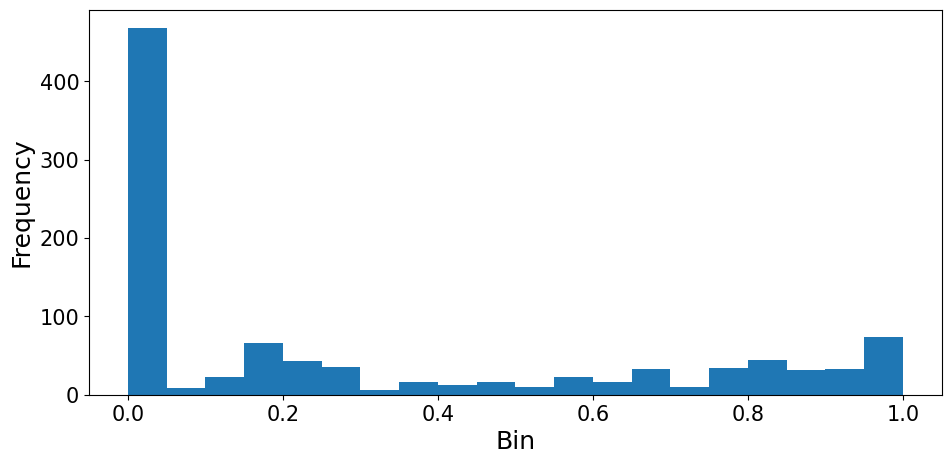

In [5]:
##
## CELL 5 randomized choice of parameters
## see read_primitive_trinomials for background work (reading from
## pdf and cleaning table)
##
import pandas as pd
df2 = pd.read_pickle("primitive_trinomials")
m = df2.shape[0]
ntrials = 1000
n = 1000

pvals = []

from random import randint, seed
seed(714)

for i in range(ntrials):
    print("trial",i)
    row = randint(0,m-1)
    q = int(df2["n"][row]) 
    k_entry = randint(0,len(df2.iloc[row,3])-1)
    r = df2["klist"][row][k_entry]
    el = q*2
    u = make_u(q,r,el,n)
    results = do_tests(u,nbins=20)
    pvals.append(results["chisq_p"])

import matplotlib.pyplot as plt
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Bin",fontsize=15)
plt.ylabel("Frequency",fontsize=15)
plt.hist(pvals,bins=nbins)
plt.savefig('Figure6.png')
plt.show()